#03_feature_engineering_evaluation.ipynb

# Feature Engineering Evaluation\n
\n
This notebook evaluates whether engineered wearable features align with the underlying physiological signals.\n
\n
Goals:\n
- Validate resting HR estimates\n
- Validate nightly HRV estimates\n
- Inspect sleep structure\n
- Inspect HR zone behavior\n
- Compare raw vs smoothed signals\n
- Ensure extracted features are physiologically interpretable

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Patch

# Allow notebook to access src/
sys.path.append(os.path.abspath('..'))

from src.data_generation import generate_wearable_data
from src.preprocessing import preprocess_data
from src.features import generate_features

## Generate Pipeline Data

In [2]:
raw_df = generate_wearable_data(days=5)

processed_df = preprocess_data(raw_df)

features_df = generate_features(processed_df)

## Daily Feature Summary

In [3]:
features_df

,date,resting_hr,nightly_hrv,sleep_duration_hours,sleep_efficiency,rem_sleep_pct,deep_sleep_pct,light_sleep_pct,daily_activity_load,active_minutes,zone1_minutes,zone2_minutes,zone3_minutes,zone4_minutes,zone5_minutes,avg_hr,max_hr,min_hr
0,2024-01-01,36.000681,60.918298,8.0,100.0,25.0,18.75,56.25,349.946008,62,1335,34,23,22,16.0,66.877771,156.144196,35.410514
1,2024-01-02,36.291996,60.824191,8.0,100.0,25.0,18.75,56.25,312.297608,50,1368,29,22,21,NaN,65.865178,142.519797,35.791026
2,2024-01-03,36.242358,60.647138,8.0,100.0,25.0,18.75,56.25,376.275022,73,1328,37,25,21,29.0,67.314244,166.198747,35.361992
3,2024-01-04,36.456294,61.097415,8.0,100.0,25.0,18.75,56.25,350.919079,62,1356,29,23,23,9.0,66.704282,152.571585,35.821747
4,2024-01-05,35.979632,60.856404,8.0,100.0,25.0,18.75,56.25,355.425543,64,1287,62,28,25,29.0,66.928882,168.425874,34.961299


## Multi-Day Signal Overview

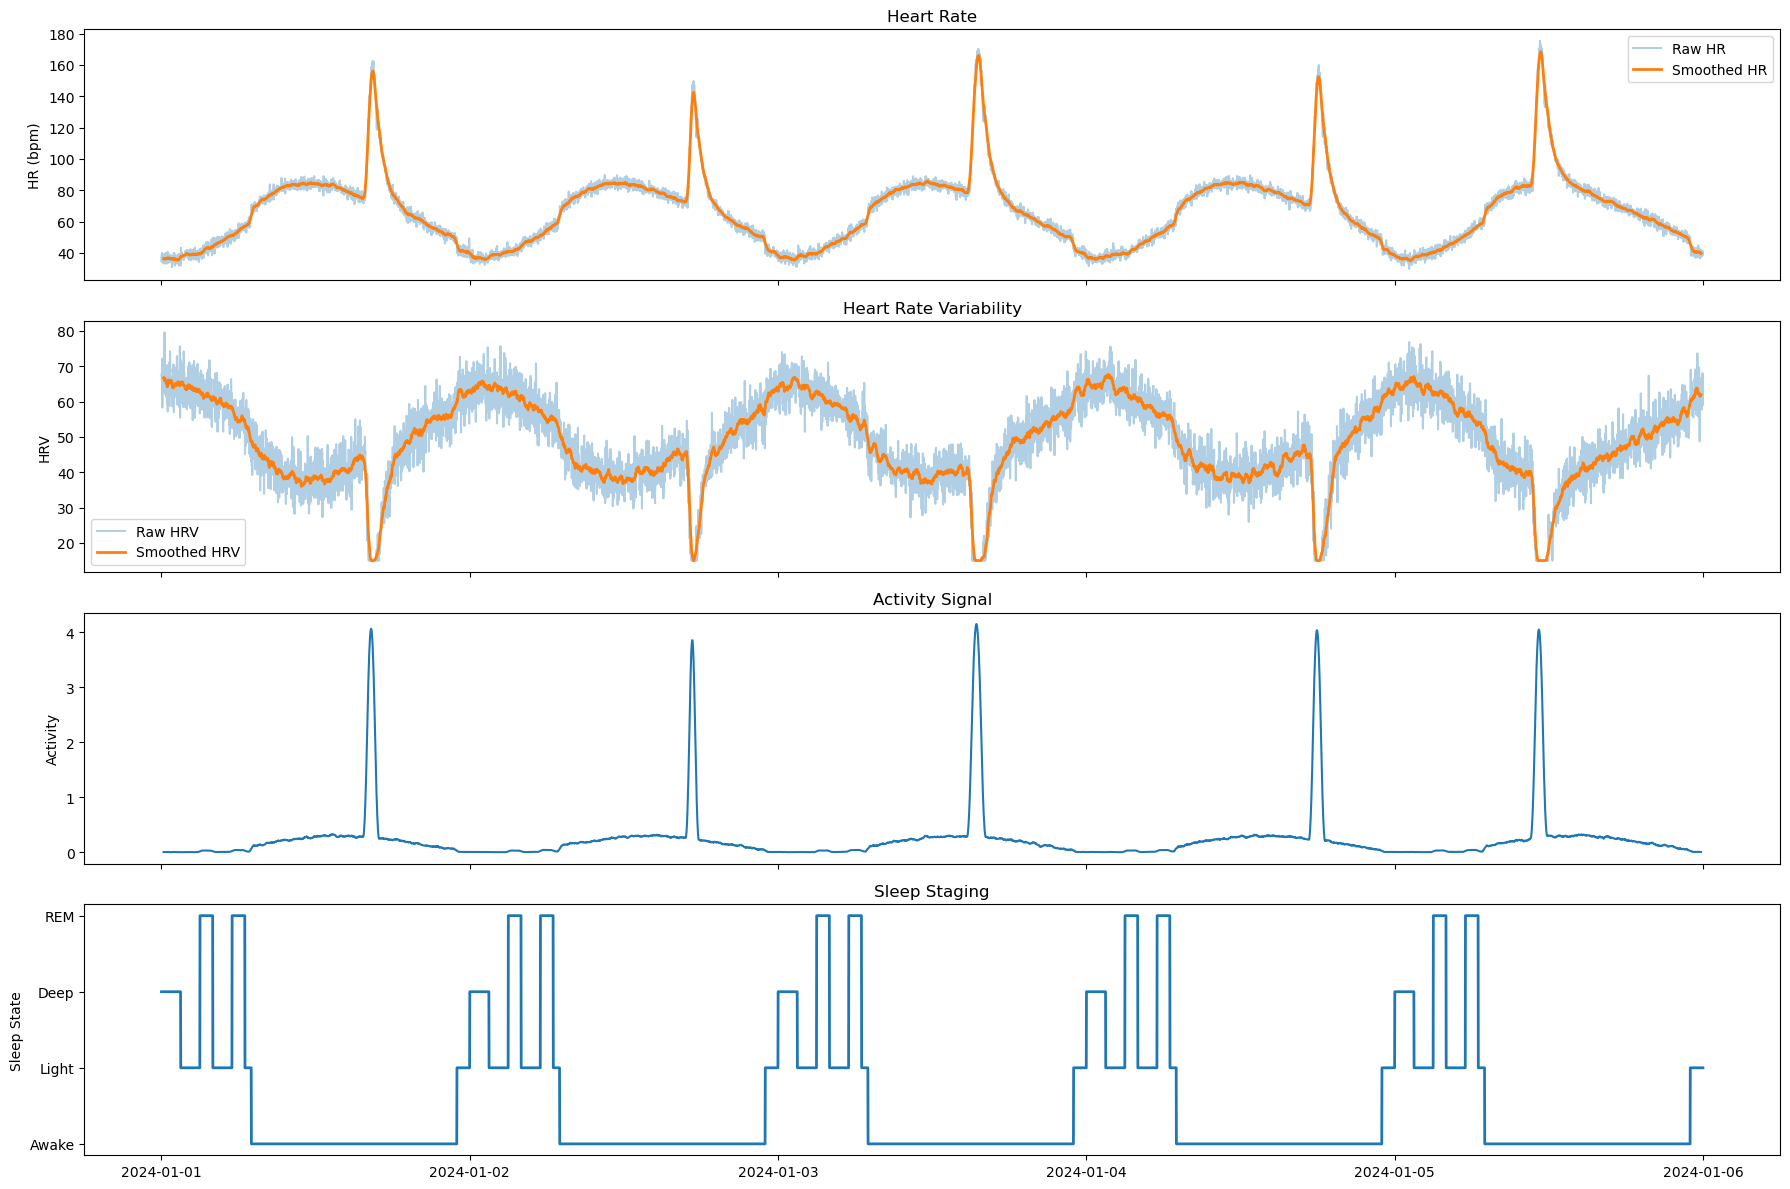

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

# =====================================================
# Heart Rate
# =====================================================

axes[0].plot(
    processed_df['timestamp'],
    processed_df['hr'],
    alpha=0.35,
    label='Raw HR'
)

axes[0].plot(
    processed_df['timestamp'],
    processed_df['hr_smooth'],
    linewidth=2,
    label='Smoothed HR'
)

axes[0].set_ylabel('HR (bpm)')
axes[0].set_title('Heart Rate')
axes[0].legend()


# =====================================================
# HRV
# =====================================================

axes[1].plot(
    processed_df['timestamp'],
    processed_df['hrv'],
    alpha=0.35,
    label='Raw HRV'
)

axes[1].plot(
    processed_df['timestamp'],
    processed_df['hrv_smooth'],
    linewidth=2,
    label='Smoothed HRV'
)

axes[1].set_ylabel('HRV')
axes[1].set_title('Heart Rate Variability')
axes[1].legend()


# =====================================================
# Activity
# =====================================================

axes[2].plot(
    processed_df['timestamp'],
    processed_df['activity_smooth'],
    linewidth=1.5
)

axes[2].set_ylabel('Activity')
axes[2].set_title('Activity Signal')


# =====================================================
# Sleep State
# =====================================================

axes[3].plot(
    processed_df['timestamp'],
    processed_df['sleep_state'],
    linewidth=2
)

axes[3].set_ylabel('Sleep State')
axes[3].set_title('Sleep Staging')
axes[3].set_yticks([0,1,2,3])
axes[3].set_yticklabels(['Awake','Light','Deep','REM'])

plt.tight_layout()
plt.show()

## Resting HR Validation

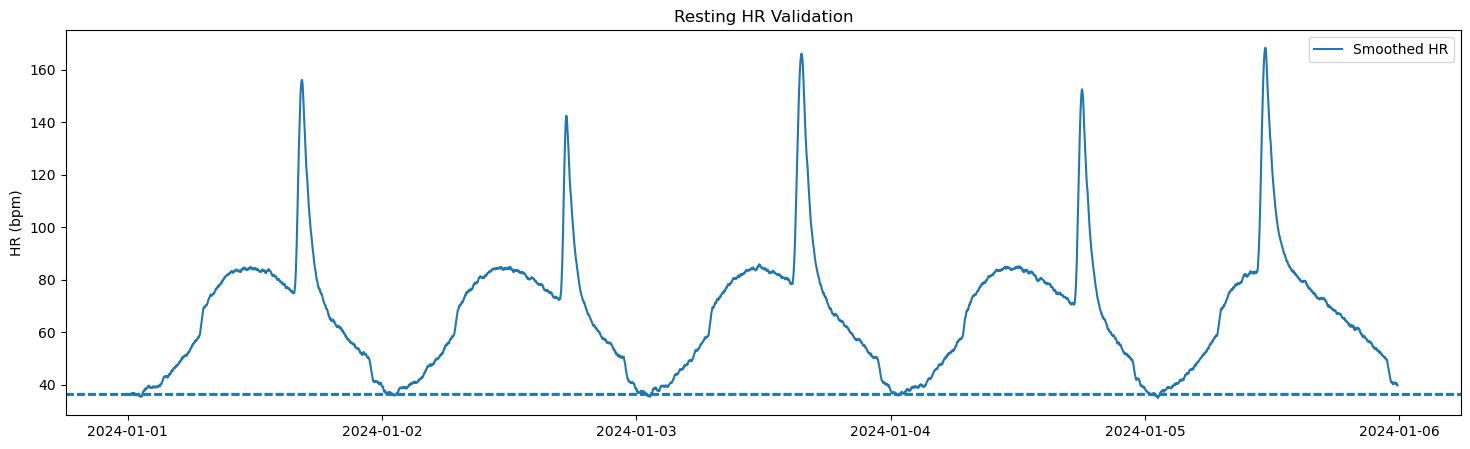

In [5]:
fig, ax = plt.subplots(figsize=(18, 5))

ax.plot(
    processed_df['timestamp'],
    processed_df['hr_smooth'],
    linewidth=1.5,
    label='Smoothed HR'
)

for _, row in features_df.iterrows():

    ax.axhline(
        row['resting_hr'],
        linestyle='--',
        alpha=0.7
    )

ax.set_title('Resting HR Validation')
ax.set_ylabel('HR (bpm)')
ax.legend()

plt.show()

## HR Zone Visualization

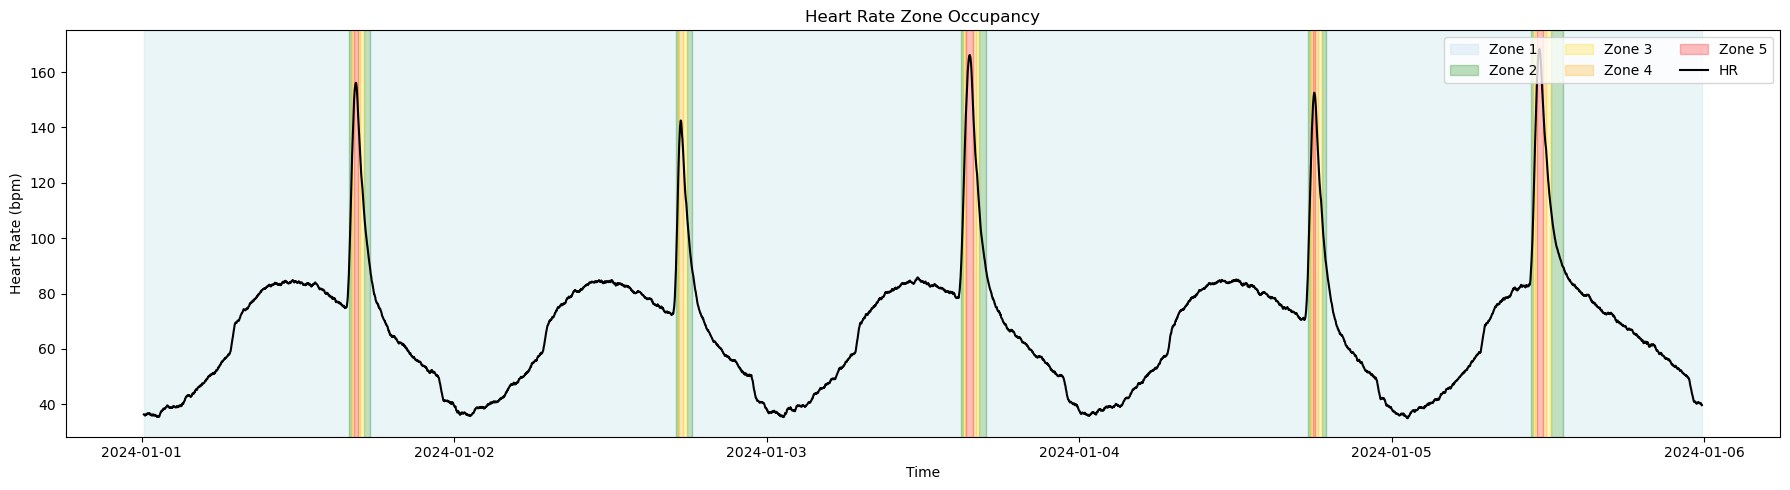

In [10]:
fig, ax = plt.subplots(figsize=(18, 5))

hr = processed_df["hr_smooth"]

# =====================================================
# Zone definitions
# =====================================================

zones = [
    (0, 90, "Zone 1"),
    (90, 110, "Zone 2"),
    (110, 130, "Zone 3"),
    (130, 150, "Zone 4"),
    (150, 220, "Zone 5")
]

colors = [
    "lightblue",
    "green",
    "gold",
    "orange",
    "red"
]

# =====================================================
# Shade time periods spent in each zone
# =====================================================

for (low, high, label), color in zip(zones, colors):

    mask = (hr >= low) & (hr < high)

    # ---------------------------------------------
    # Find contiguous time regions
    # ---------------------------------------------

    zone_regions = []

    in_region = False

    for i in range(len(mask)):

        if mask.iloc[i] and not in_region:

            start_time = processed_df["timestamp"].iloc[i]
            in_region = True

        elif not mask.iloc[i] and in_region:

            end_time = processed_df["timestamp"].iloc[i]

            zone_regions.append((
                start_time,
                end_time
            ))

            in_region = False

    # Handle case where region continues to end

    if in_region:

        zone_regions.append((
            start_time,
            processed_df["timestamp"].iloc[-1]
        ))

    # ---------------------------------------------
    # Plot shaded regions
    # ---------------------------------------------

    for j, (start, end) in enumerate(zone_regions):

        ax.axvspan(
            start,
            end,
            color=color,
            alpha=0.25,
            label=label if j == 0 else None
        )

# =====================================================
# Overlay HR signal
# =====================================================

ax.plot(
    processed_df["timestamp"],
    hr,
    color="black",
    linewidth=1.5,
    label="HR"
)

# =====================================================
# Formatting
# =====================================================

ax.set_title("Heart Rate Zone Occupancy")
ax.set_ylabel("Heart Rate (bpm)")
ax.set_xlabel("Time")

ax.legend(
    loc="upper right",
    ncol=3
)

plt.tight_layout()
plt.show()

## Daily Sleep Features

In [11]:
sleep_features = features_df[[
    'date',
    'sleep_duration_hours',
    'sleep_efficiency',
    'rem_sleep_pct',
    'deep_sleep_pct'
]]

sleep_features

,date,sleep_duration_hours,sleep_efficiency,rem_sleep_pct,deep_sleep_pct
0,2024-01-01,8.0,100.0,25.0,18.75
1,2024-01-02,8.0,100.0,25.0,18.75
2,2024-01-03,8.0,100.0,25.0,18.75
3,2024-01-04,8.0,100.0,25.0,18.75
4,2024-01-05,8.0,100.0,25.0,18.75


## Feature Interpretation Notes\n
\n
Questions to ask while inspecting plots:\n
\n
- Does resting HR align with overnight minima?\n
- Does HRV increase during sleep?\n
- Do exercise periods elevate HR appropriately?\n
- Do HR zones correspond to visible exertion?\n
- Does sleep staging align with reduced HR/activity?\n
- Are there unrealistic transitions or artifacts?\n
- Do the extracted features match intuition?